In [33]:
import numpy as np, pandas as pd, warnings, matplotlib.pyplot as plt, seaborn as sns

warnings.filterwarnings("ignore")

### Data Dictionary
S.No.,Variable Name�,Meaning
1,CustomerID�,The unique ID of each customer
2,Gender�,The gender of a person
3,SeniorCitizen,Whether a customer can be classified as a senior citizen.
4,Partner�,If a customer is married/ in a live-in relationship.
5,Dependents,If a customer has dependents (children/ retired parents)
6,Tenure,The time for which a customer has been using the service.
7,PhoneService �,Whether a customer has a landline phone service along with the internet service.
8,MultipleLines,Whether a customer has multiple lines of internet connectivity.
9,InternetService�,The type of internet services chosen by the customer.
10,OnlineSecurity�,Specifies if a customer has online security.
11,OnlineBackup�,Specifies if a customer has online backup.
12,DeviceProtection�,Specifies if a customer has opted for device protection.
13,TechSupport�,Whether a customer has opted for tech support of not.
14,StreamingTV,Whether a customer has an option of TV streaming.
15,StreamingMovies�,Whether a customer has an option of Movie streaming.
16,Contract �,The type of contract a customer has chosen.
17,PaperlessBilling �,Whether a customer has opted for paperless billing.
18,PaymentMethod�,Specifies the method by which bills are paid.
19,MonthlyCharges�,Specifies the money paid by a customer each month.
20,TotalCharges�,The total money paid by the customer to the company.
21,Churn �,This is the target variable which specifies if a customer has churned or not.


## 1. Reading the data

In [2]:
churn_data = pd.read_csv("churn_data.csv")
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
customer_data = pd.read_csv("customer_data.csv")
customer_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [5]:
internet_data = pd.read_csv("internet_data.csv")
internet_data.head(10)

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,No,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Yes,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Yes,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,No phone service,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,No,DSL,Yes,Yes,No,No,No,No


## 2. Combining all data files into one

In [55]:
df = churn_data.merge(customer_data, how="inner", on="customerID").merge(
    internet_data, on="customerID", how="inner"
)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
 9   gender            7043 non-null   object 
 10  SeniorCitizen     7043 non-null   int64  
 11  Partner           7043 non-null   object 
 12  Dependents        7043 non-null   object 
 13  MultipleLines     7043 non-null   object 
 14  InternetService   7043 non-null   object 
 15  OnlineSecurity    7043 non-null   object 
 16  OnlineBackup      7043 non-null   object 


In [36]:
df

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Female,...,Yes,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No,Male,...,No,No,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Male,...,No,No,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Male,...,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Female,...,No,No,No,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,Yes,One year,Yes,Mailed check,84.80,1990.5,No,Male,...,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes
7039,2234-XADUH,72,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,Female,...,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
7040,4801-JZAZL,11,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Female,...,Yes,Yes,No phone service,DSL,Yes,No,No,No,No,No
7041,8361-LTMKD,4,Yes,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,Male,...,Yes,No,Yes,Fiber optic,No,No,No,No,No,No


In [13]:
df.describe()

,tenure,MonthlyCharges,SeniorCitizen
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.162147
std,24.559481,30.090047,0.368612
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,0.000000
50%,29.000000,70.350000,0.000000
75%,55.000000,89.850000,0.000000
max,72.000000,118.750000,1.000000


In [14]:
df.shape

(7043, 21)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
 9   gender            7043 non-null   object 
 10  SeniorCitizen     7043 non-null   int64  
 11  Partner           7043 non-null   object 
 12  Dependents        7043 non-null   object 
 13  MultipleLines     7043 non-null   object 
 14  InternetService   7043 non-null   object 
 15  OnlineSecurity    7043 non-null   object 
 16  OnlineBackup      7043 non-null   object 


## Data Preparation,

In [56]:
var_list = ["PhoneService", "Churn", "PaperlessBilling", "Partner", "Dependents"]


def binary_map(x):
    return x.map({"Yes": 1, "No": 0})


df[var_list] = df[var_list].apply(lambda x: x.map({"Yes": 1, "No": 0}))

In [38]:
df

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,Female,...,1,0,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,Male,...,0,0,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,Male,...,0,0,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Male,...,0,0,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,Female,...,0,0,No,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,1,One year,1,Mailed check,84.80,1990.5,0,Male,...,1,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes
7039,2234-XADUH,72,1,One year,1,Credit card (automatic),103.20,7362.9,0,Female,...,1,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
7040,4801-JZAZL,11,0,Month-to-month,1,Electronic check,29.60,346.45,0,Female,...,1,1,No phone service,DSL,Yes,No,No,No,No,No
7041,8361-LTMKD,4,1,Month-to-month,1,Mailed check,74.40,306.6,1,Male,...,1,0,Yes,Fiber optic,No,No,No,No,No,No


## CheckPoint 1

In [61]:
dfAnalysis = df.copy()
# multi_var=['Contract','PaymentMethod','gender','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
#  'StreamingMovies']

In [62]:
dummy = pd.get_dummies(
    dfAnalysis[["Contract", "PaymentMethod", "gender", "InternetService"]],
    dtype=int,
    drop_first=True,
)
dfAnalysis = pd.concat([dfAnalysis, dummy], axis=1)

In [63]:
dfAnalysis

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,StreamingTV,StreamingMovies,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,Female,...,No,No,0,0,0,1,0,0,0,0
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,Male,...,No,No,1,0,0,0,1,1,0,0
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,Male,...,No,No,0,0,0,0,1,1,0,0
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Male,...,No,No,1,0,0,0,0,1,0,0
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,Female,...,No,No,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,1,One year,1,Mailed check,84.80,1990.5,0,Male,...,Yes,Yes,1,0,0,0,1,1,0,0
7039,2234-XADUH,72,1,One year,1,Credit card (automatic),103.20,7362.9,0,Female,...,Yes,Yes,1,0,1,0,0,0,1,0
7040,4801-JZAZL,11,0,Month-to-month,1,Electronic check,29.60,346.45,0,Female,...,No,No,0,0,0,1,0,0,0,0
7041,8361-LTMKD,4,1,Month-to-month,1,Mailed check,74.40,306.6,1,Male,...,No,No,0,0,0,0,1,1,1,0


In [70]:
multi_var_list = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies",
    "TechSupport",
]
multi_dummies = pd.get_dummies(
    dfAnalysis[multi_var_list], prefix=multi_var_list, dtype=int
)
multi_dummies.drop(
    [
        "MultipleLines_No phone service",
        "OnlineBackup_No internet service",
        "OnlineSecurity_No internet service",
        "OnlineBackup_No internet service",
        "DeviceProtection_No internet service",
        "StreamingTV_No internet service",
        "StreamingMovies_No internet service",
    ],
    axis=1,
    inplace=True,
)
dfAnalysis = pd.concat([dfAnalysis, multi_dummies], axis=1)
dfAnalysis.drop(
    ["Contract", "PaymentMethod", "gender", "InternetService"], axis=1, inplace=True
)
dfAnalysis.drop(multi_var_list, axis=1, inplace=True)

In [73]:
dfAnalysis.head(10)

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,1,0,0,1,1,0,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,0,1,1,0,0,1,1,0,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,1,0,1,1,0,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,1,1,0,0,1,1,0,1,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,0,1,0,1,0,1,0
5,9305-CDSKC,8,1,1,99.65,820.5,1,0,0,0,...,1,0,1,0,0,1,0,1,0,1
6,1452-KIOVK,22,1,1,89.10,1949.4,0,0,0,1,...,1,0,0,1,1,0,0,1,1,0
7,6713-OKOMC,10,0,0,29.75,301.9,0,0,0,0,...,0,1,1,0,1,0,1,0,1,0
8,7892-POOKP,28,1,1,104.80,3046.05,1,0,1,0,...,1,0,1,0,0,1,0,1,0,1
9,6388-TABGU,62,1,0,56.15,3487.95,0,0,0,1,...,0,1,0,1,1,0,1,0,1,0


In [ ]:
dfAnalysis = dfAnalysis[~(dfAnalysis["TotalCharges"] == " ")]

pd.to_numeric(dfAnalysis["TotalCharges"])

In [91]:
dfAnalysis["TotalCharges"] = dfAnalysis["TotalCharges"].astype(float)

In [92]:
dfAnalysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   object 
 1   tenure                                 7032 non-null   int64  
 2   PhoneService                           7032 non-null   int64  
 3   PaperlessBilling                       7032 non-null   int64  
 4   MonthlyCharges                         7032 non-null   float64
 5   TotalCharges                           7032 non-null   float64
 6   Churn                                  7032 non-null   int64  
 7   SeniorCitizen                          7032 non-null   int64  
 8   Partner                                7032 non-null   int64  
 9   Dependents                             7032 non-null   int64  
 10  Contract_One year                      7032 non-null   int64  
 11  Contract_

In [93]:
dfAnalysis

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,TechSupport_No,TechSupport_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,1,1,0,1,0,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.50,0,0,0,0,...,1,0,0,1,1,0,1,0,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,1,1,0,1,0,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,1,0,0,1,1,0,1,0,0,1
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,1,1,84.80,1990.50,0,0,1,1,...,1,0,0,1,0,1,0,1,0,1
7039,2234-XADUH,72,1,1,103.20,7362.90,0,0,1,1,...,0,1,0,1,0,1,0,1,1,0
7040,4801-JZAZL,11,0,1,29.60,346.45,0,0,1,1,...,1,0,1,0,1,0,1,0,1,0
7041,8361-LTMKD,4,1,1,74.40,306.60,1,1,1,0,...,1,0,1,0,1,0,1,0,1,0


In [97]:
# new tosee
dfAnalysis[["tenure", "MonthlyCharges", "SeniorCitizen", "TotalCharges"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

,tenure,MonthlyCharges,SeniorCitizen,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,0.162400,2283.300441
std,24.545260,30.085974,0.368844,2266.771362
min,1.000000,18.250000,0.000000,18.800000
25%,9.000000,35.587500,0.000000,401.450000
50%,29.000000,70.350000,0.000000,1397.475000
75%,55.000000,89.862500,0.000000,3794.737500
90%,69.000000,102.645000,1.000000,5976.640000
95%,72.000000,107.422500,1.000000,6923.590000
99%,72.000000,114.734500,1.000000,8039.883000


## Step 4:Model Building
### Test Train Split,

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
# CheckPoint 2
dfModel = dfAnalysis.copy()
X = dfModel.drop(["Churn", "customerID"], axis=1)
y = dfModel["Churn"]

In [100]:
X.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,TechSupport_No,TechSupport_Yes
0,1,0,1,29.85,29.85,0,1,0,0,0,...,0,1,1,0,1,0,1,0,1,0
1,34,1,0,56.95,1889.50,0,0,0,1,0,...,1,0,0,1,1,0,1,0,1,0
2,2,1,1,53.85,108.15,0,0,0,0,0,...,0,1,1,0,1,0,1,0,1,0
3,45,0,0,42.30,1840.75,0,0,0,1,0,...,1,0,0,1,1,0,1,0,0,1
4,2,1,1,70.70,151.65,0,0,0,0,0,...,1,0,1,0,1,0,1,0,1,0


In [101]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, train_size=0.7, random_state=100
)

## Step 5. Feature Scaling

In [103]:
from sklearn.preprocessing import StandardScaler  # (var-mean)/(std)

In [104]:
scaler = StandardScaler()

In [108]:
X_train_scaler = X_train.copy()

num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]
X_train_scaler[num_vars] = scaler.fit_transform(X_train_scaler[num_vars])

In [109]:
X_train_scaler.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,TechSupport_No,TechSupport_Yes
879,0.019693,1,1,-0.338074,-0.276449,0,0,0,0,0,...,0,1,1,0,1,0,1,0,1,0
5790,0.305384,0,1,-0.464443,-0.112702,0,1,1,0,0,...,0,1,1,0,0,1,0,1,1,0
6498,-1.286319,1,1,0.581425,-0.974430,0,0,0,0,0,...,0,1,0,1,1,0,1,0,1,0
880,-0.919003,1,1,1.505913,-0.550676,0,0,0,0,0,...,0,1,0,1,0,1,0,1,0,1
2784,-1.163880,1,1,1.106854,-0.835971,0,0,1,0,0,...,1,0,0,1,0,1,0,1,0,1


In [110]:
X_train_scaler[num_vars].describe()

,tenure,MonthlyCharges,TotalCharges
count,4.922000e+03,4.922000e+03,4.922000e+03
mean,7.506750e-17,-2.064356e-16,1.183757e-16
std,1.000102e+00,1.000102e+00,1.000102e+00
min,-1.286319e+00,-1.548555e+00,-1.002408e+00
25%,-9.598159e-01,-9.665930e-01,-8.344722e-01
50%,-1.435582e-01,1.823658e-01,-3.877341e-01
75%,9.583897e-01,8.341630e-01,6.589888e-01
max,1.611396e+00,1.793569e+00,2.818847e+00


In [121]:
percentage_churn = round(sum(y) / len(y) * 100, 1)
percentage_churn

26.6

**Churn Rate and Class Imbalance**

Another thing to note here was the Churn Rate which Rahim talked about at the end of the video. You saw that the data has almost 27% churn rate. Checking the churn rate is important since you usually want your data to have a balance between the 0s and 1s (in this case churn and not-churn).



The reason for having a balance is simple. Let’s do a simple thought experiment - if you had a data with, say, 95% not-churn (0) and just 5% churn (1), then even if you predict everything as 0, you would still get a model which is 95% accurate (though it is, of course, a bad model). This problem is called class-imbalance and you'll learn to solve such cases later.



Fortunately, in this case, we have about 27% churn rate. This is neither exactly 'balanced' (which a 50-50 ratio would be called) nor heavily imbalanced. So we'll not have to do any special treatment for this dataset.

In [123]:
(20 - 50) / 12

-2.5

In [ ]:
dfModel.drop("customerID", axis=1, inplace=True)

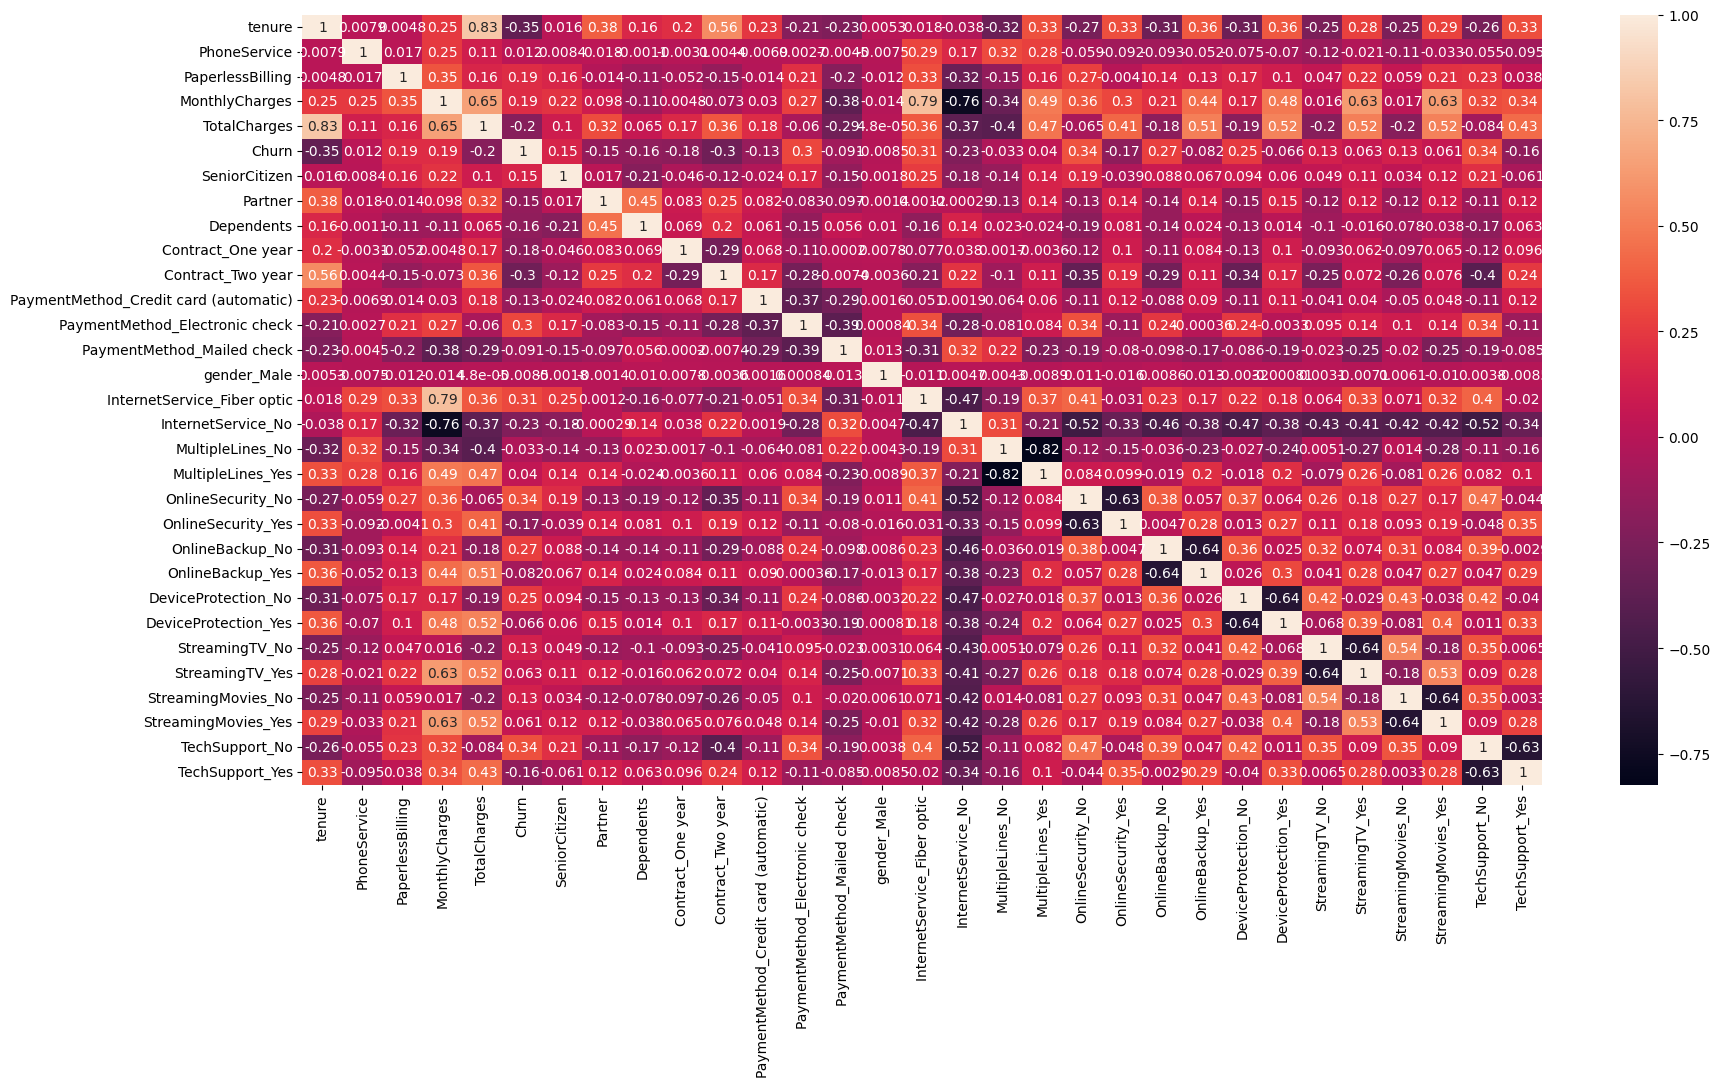

In [129]:
plt.figure(figsize=(20, 10))

sns.heatmap(dfModel.corr(), annot=True)
plt.show()

If you look at the correlations between these dummy variables with their complimentary dummy variables, i.e. ‘MultipleLines_No’ with ‘MultipleLines_Yes’ or ‘OnlineSecurity_No’ with ‘OnlineSecurity_Yes’, you’ll find out they’re highly correlated. Have a look at the heat map below:


If you check the highlighted portion, you’ll see that there are high correlations among the pairs of dummy variables which were created for the same column. For example, ‘StreamingTV_No’ has a correlation of -0.64 with ‘StreamingTV_Yes’. So it is better than we drop one of these variables from each pair as they won’t add much value to the model. The choice of which of these pair of variables you desire to drop is completely up to you; we’ve chosen to drop all the 'Nos' because the 'Yeses' are generally more interpretable and easy-to-work-with variables.

## Step 6. Drop Highly Correlated Features

In [131]:
X_test = X_test.drop(
    [
        "MultipleLines_No",
        "OnlineSecurity_No",
        "OnlineBackup_No",
        "DeviceProtection_No",
        "TechSupport_No",
        "StreamingTV_No",
        "StreamingMovies_No",
    ],
    axis=1,
)
X_train = X_train.drop(
    [
        "MultipleLines_No",
        "OnlineSecurity_No",
        "OnlineBackup_No",
        "DeviceProtection_No",
        "TechSupport_No",
        "StreamingTV_No",
        "StreamingMovies_No",
    ],
    axis=1,
)

In [136]:
X_train_scaler = X_train_scaler.drop(
    [
        "MultipleLines_No",
        "OnlineSecurity_No",
        "OnlineBackup_No",
        "DeviceProtection_No",
        "TechSupport_No",
        "StreamingTV_No",
        "StreamingMovies_No",
    ],
    axis=1,
)

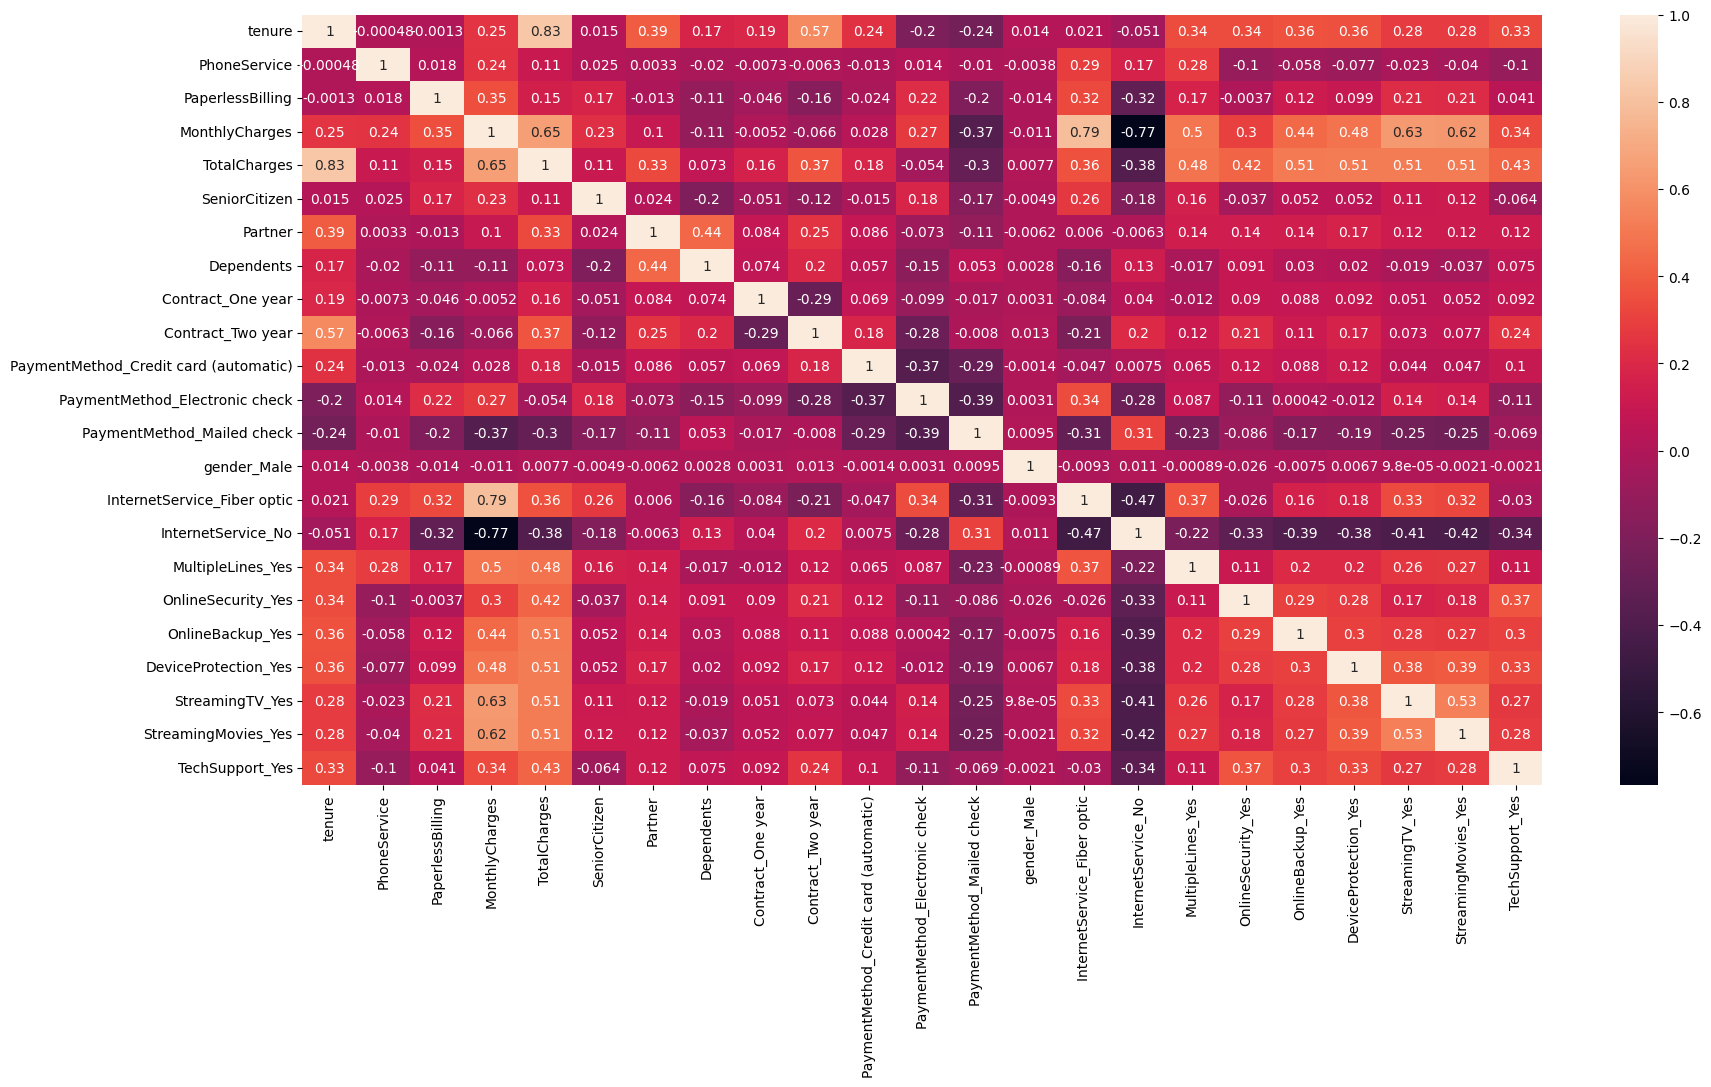

In [137]:
plt.figure(figsize=(20, 10))

sns.heatmap(X_train_scaler.corr(), annot=True)
plt.show()

## Step 7Building our first model

In [134]:
import statsmodels.api as sm

In [140]:
ols = sm.GLM(y_train, sm.add_constant(X_train_scaler), family=sm.families.Binomial())
print(ols.fit().summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4898
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2004.7
Date:                Wed, 21 May 2025   Deviance:                       4009.4
Time:                        04:25:23   Pearson chi2:                 6.07e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2844
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [141]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Variance Inflation done after RFE

In [142]:
vif = pd.DataFrame()
vif["Features"] = X_train.columns
vif["VIF"] = [
    variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])
]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
3,MonthlyCharges,216.89
1,PhoneService,48.14
4,TotalCharges,21.51
0,tenure,20.68
14,InternetService_Fiber optic,18.02
15,InternetService_No,8.32
21,StreamingMovies_Yes,5.15
20,StreamingTV_Yes,4.97
9,Contract_Two year,3.50
19,DeviceProtection_Yes,2.97


## Step 8. Using sklearn feature elimination RFE

In [146]:
# Importing Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

In [144]:
logreg = LogisticRegression()

### RFE Features to select to be given manually, bad scenario

In [153]:
n = len(X_train_scaler.columns)
features_to_select_randomly_input = 15
rfe = RFE(
    logreg, n_features_to_select=features_to_select_randomly_input
)  # running RFE with 15 variables as output
rfe.fit(X_train_scaler, y_train)

RFE(estimator=LogisticRegression(), n_features_to_select=15)

In [155]:
X_train_scaler.columns[rfe.support_]

Index(['tenure', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'SeniorCitizen', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'MultipleLines_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'TechSupport_Yes'],
      dtype='object')

In [160]:
var_output_dict = {
    "column": X_train_scaler.columns,
    "support": rfe.support_,
    "ranking": rfe.ranking_,
}

In [163]:
list([X_train_scaler.columns, rfe.support_])

[Index(['tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
        'TotalCharges', 'SeniorCitizen', 'Partner', 'Dependents',
        'Contract_One year', 'Contract_Two year',
        'PaymentMethod_Credit card (automatic)',
        'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
        'gender_Male', 'InternetService_Fiber optic', 'InternetService_No',
        'MultipleLines_Yes', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
        'DeviceProtection_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
        'TechSupport_Yes'],
       dtype='object'),
 array([ True, False,  True,  True,  True,  True, False, False,  True,
         True,  True, False,  True, False,  True,  True,  True, False,
        False, False,  True,  True,  True])]

In [171]:
from collections import defaultdict

l = defaultdict(list)
for a, b, c in zip(X_train_scaler.columns, rfe.support_, rfe.ranking_):
    l["column"].append(a)
    l["support"].append(b)
    l["ranking"].append(c)

In [177]:
list(zip(X_train_scaler.columns, rfe.support_, rfe.ranking_))

[('tenure', np.True_, np.int64(1)),
 ('PhoneService', np.False_, np.int64(3)),
 ('PaperlessBilling', np.True_, np.int64(1)),
 ('MonthlyCharges', np.True_, np.int64(1)),
 ('TotalCharges', np.True_, np.int64(1)),
 ('SeniorCitizen', np.True_, np.int64(1)),
 ('Partner', np.False_, np.int64(7)),
 ('Dependents', np.False_, np.int64(6)),
 ('Contract_One year', np.True_, np.int64(1)),
 ('Contract_Two year', np.True_, np.int64(1)),
 ('PaymentMethod_Credit card (automatic)', np.True_, np.int64(1)),
 ('PaymentMethod_Electronic check', np.False_, np.int64(4)),
 ('PaymentMethod_Mailed check', np.True_, np.int64(1)),
 ('gender_Male', np.False_, np.int64(8)),
 ('InternetService_Fiber optic', np.True_, np.int64(1)),
 ('InternetService_No', np.True_, np.int64(1)),
 ('MultipleLines_Yes', np.True_, np.int64(1)),
 ('OnlineSecurity_Yes', np.False_, np.int64(2)),
 ('OnlineBackup_Yes', np.False_, np.int64(5)),
 ('DeviceProtection_Yes', np.False_, np.int64(9)),
 ('StreamingTV_Yes', np.True_, np.int64(1)),
 ('

In [178]:
X_train_scaler.columns[~rfe.support_]

Index(['PhoneService', 'Partner', 'Dependents',
       'PaymentMethod_Electronic check', 'gender_Male', 'OnlineSecurity_Yes',
       'OnlineBackup_Yes', 'DeviceProtection_Yes'],
      dtype='object')

In [179]:
selected_features = X_train_scaler.columns[rfe.support_]

In [180]:
selected_features

Index(['tenure', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'SeniorCitizen', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'MultipleLines_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'TechSupport_Yes'],
      dtype='object')

### Assessing model with statsmodel

In [181]:
X_train_sm = sm.add_constant(X_train_scaler[selected_features])
ols_rfe = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
res_rfe = ols_rfe.fit()
res_rfe.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4906
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2011.1
Date:                Wed, 21 May 2025   Deviance:                       4022.2
Time:                        05:19:46   Pearson chi2:                 6.25e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2825
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.2462      0.189    -11.879      0.000      -2.617      -1.876
tenure                                   -1.5596      0.187     -8.334      0.000      -1.926      -1.193
PaperlessBilling                          0.3436      0.090      3.832      0.000       0.168       0.519
MonthlyCharges                           -0.9692      0.199     -4.878      0.000      -1.359      -0.580
TotalCharges                              0.7421      0.197      3.764      0.000       0.356       1.128
SeniorCitizen                             0.4296      0.100      4.312      0.000       0.234       0.625
Contract_One year                        -0.6830      0.128     -5.342      0.000      -0.934      -0.432
Contract_Two year                        -1.2931      0.211     -6.138      0.000      -1.706      -0.880
PaymentMethod_Credit card (automatic)    -0.3724      0.113     -3.308      0.001      -0.593      -0.152
PaymentMethod_Mailed check               -0.3723      0.111     -3.345      0.001      -0.591      -0.154
InternetService_Fiber optic               1.5865      0.216      7.342      0.000       1.163       2.010
InternetService_No                       -1.6897      0.216     -7.830      0.000      -2.113      -1.267
MultipleLines_Yes                         0.3779      0.104      3.640      0.000       0.174       0.581
StreamingTV_Yes                           0.5796      0.114      5.102      0.000       0.357       0.802
StreamingMovies_Yes                       0.4665      0.111      4.197      0.000       0.249       0.684
TechSupport_Yes                          -0.2408      0.109     -2.210      0.027      -0.454      -0.027
=========================================================================================================
"""

In [182]:
y_train_pred = res_rfe.predict(X_train_sm)

In [183]:
y_train_pred

879     0.192642
5790    0.275624
6498    0.599507
880     0.513571
2784    0.648233
          ...   
79      0.015336
3934    0.126458
5964    0.039247
6947    0.129142
5649    0.031459
Length: 4922, dtype: float64

In [185]:
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred

array([0.19264205, 0.27562384, 0.59950707, ..., 0.03924737, 0.12914179,
       0.03145932], shape=(4922,))

### Creating dataframe with actual churn and predicted probabilities

In [186]:
y_train_pred_final = pd.DataFrame(
    {"Churn": y_train.values, "Churn Probability": y_train_pred}
)
y_train_pred_final

,Churn,Churn Probability
0,0,0.192642
1,0,0.275624
2,1,0.599507
3,1,0.513571
4,1,0.648233
...,...,...
4917,0,0.015336
4918,0,0.126458
4919,0,0.039247
4920,0,0.129142


In [189]:
y_train_pred_final["CustID"] = y_train.index

In [190]:
y_train_pred_final

,Churn,Churn Probability,CustID
0,0,0.192642,879
1,0,0.275624,5790
2,1,0.599507,6498
3,1,0.513571,880
4,1,0.648233,2784
...,...,...,...
4917,0,0.015336,79
4918,0,0.126458,3934
4919,0,0.039247,5964
4920,0,0.129142,6947


In [192]:
y_train_pred_final["predicted"] = y_train_pred_final["Churn Probability"].apply(
    lambda x: 1 if x > 0.5 else 0
)
y_train_pred_final.head()

,Churn,Churn Probability,CustID,predicted
0,0,0.192642,879,0
1,0,0.275624,5790,0
2,1,0.599507,6498,1
3,1,0.513571,880,1
4,1,0.648233,2784,1


 RFE assigns ranks to the different variables based on their significance. While 1 means that the variable should be selected, a rank > 1 tells you that the variable is insignificant. The ranking given to 'gender_Male' by RFE is 9 which is the highest and hence, it is the most insignificant variable present in the RFE output.

In [193]:
actual_yes = y_train_pred_final["Churn"].sum()
actual_no = len(y_train_pred_final) - actual_yes
predicted_yes = y_train_pred_final["predicted"].sum()
predicted_no = len(y_train_pred_final) - predicted_yes
confusion_matrix = pd.DataFrame(
    {"No": [actual_no, predicted_no], "Yes": [actual_yes, predicted_yes]},
    index=["No Churn", "Churn"],
)

In [195]:
confusion_matrix

,No,Yes
No Churn,3635,1287
Churn,3849,1073


In [196]:
from sklearn import metrics

In [198]:
confusion = metrics.confusion_matrix(
    y_train_pred_final.Churn, y_train_pred_final.predicted
)
confusion

array([[3275,  360],
       [ 574,  713]])

In [211]:
incorrect_percentage = ((confusion[1][0] + confusion[0][1]) / (confusion.sum())) * 100

In [213]:
accuracy = (100 - incorrect_percentage) / 100

### Accuracy

In [214]:
accuracy_automatic = metrics.accuracy_score(
    y_train_pred_final.Churn, y_train_pred_final.predicted
)

In [215]:
assert accuracy == accuracy_automatic

So using the confusion matrix, you got an accuracy of about 80.8% which seems to be a good number to begin with. The steps you need to calculate accuracy are:


Create the confusion matrix

Calculate the accuracy by applying the 'accuracy_score' function to the above matrix

The code used to do this was:


##### Create confusion matrix

confusion = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final.predicted)

###### Calculate accuracy

print(metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.predicted))

In [217]:
550 / 700

0.7857142857142857

In [221]:
vif = pd.DataFrame()
vif["Features"] = X_train_scaler[selected_features].columns
vif["VIF"] = [
    variance_inflation_factor(X_train_scaler[selected_features].values, i)
    for i in range(X_train_scaler[selected_features].shape[1])
]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)

In [222]:
vif

,Features,VIF
2,MonthlyCharges,14.85
3,TotalCharges,10.42
0,tenure,7.38
9,InternetService_Fiber optic,5.61
10,InternetService_No,5.27
6,Contract_Two year,3.14
12,StreamingTV_Yes,2.79
13,StreamingMovies_Yes,2.79
1,PaperlessBilling,2.76
11,MultipleLines_Yes,2.38


In [224]:
selected_features = selected_features.drop("MonthlyCharges")

In [225]:
selected_features

Index(['tenure', 'PaperlessBilling', 'TotalCharges', 'SeniorCitizen',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'MultipleLines_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'TechSupport_Yes'],
      dtype='object')

## Step 9. Building Model 2

In [227]:
X_train_sm = sm.add_constant(X_train_scaler[selected_features])
ols_rfe = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
res_rfe = ols_rfe.fit()
res_rfe.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4907
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2023.1
Date:                Wed, 21 May 2025   Deviance:                       4046.2
Time:                        06:38:56   Pearson chi2:                 5.80e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2790
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.5971      0.130    -12.296      0.000      -1.852      -1.343
tenure                                   -1.3286      0.180     -7.401      0.000      -1.681      -0.977
PaperlessBilling                          0.3533      0.089      3.958      0.000       0.178       0.528
TotalCharges                              0.4347      0.186      2.340      0.019       0.071       0.799
SeniorCitizen                             0.4569      0.099      4.601      0.000       0.262       0.652
Contract_One year                        -0.7289      0.127     -5.729      0.000      -0.978      -0.480
Contract_Two year                        -1.3277      0.210     -6.322      0.000      -1.739      -0.916
PaymentMethod_Credit card (automatic)    -0.3870      0.112     -3.442      0.001      -0.607      -0.167
PaymentMethod_Mailed check               -0.3618      0.110     -3.274      0.001      -0.578      -0.145
InternetService_Fiber optic               0.6888      0.109      6.297      0.000       0.474       0.903
InternetService_No                       -0.9555      0.156     -6.120      0.000      -1.262      -0.649
MultipleLines_Yes                         0.1700      0.094      1.814      0.070      -0.014       0.354
StreamingTV_Yes                           0.2881      0.096      2.996      0.003       0.100       0.477
StreamingMovies_Yes                       0.1944      0.096      2.031      0.042       0.007       0.382
TechSupport_Yes                          -0.4371      0.101     -4.307      0.000      -0.636      -0.238
=========================================================================================================
"""

### Multi Collinearity


In [229]:
vif = pd.DataFrame()
vif["Features"] = X_train_scaler[selected_features].columns
vif["VIF"] = [
    variance_inflation_factor(X_train_scaler[selected_features].values, i)
    for i in range(X_train_scaler[selected_features].shape[1])
]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
2,TotalCharges,7.46
0,tenure,6.90
5,Contract_Two year,3.07
8,InternetService_Fiber optic,2.96
12,StreamingMovies_Yes,2.62
11,StreamingTV_Yes,2.59
1,PaperlessBilling,2.55
9,InternetService_No,2.44
10,MultipleLines_Yes,2.27
13,TechSupport_Yes,1.95


### Confusion Matrix 2

In [230]:
y_train_pred = res_rfe.predict(X_train_sm)
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred_final = pd.DataFrame(
    {"Churn": y_train.values, "Churn Probability": y_train_pred}
)

y_train_pred_final["predicted"] = y_train_pred_final["Churn Probability"].apply(
    lambda x: 1 if x > 0.5 else 0
)
confusion = metrics.confusion_matrix(
    y_train_pred_final.Churn, y_train_pred_final.predicted
)

confusion

array([[3269,  366],
       [ 590,  697]])

### Accuracy Model 2

In [234]:
metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.predicted)

0.8057700121901666

## Step 10. Building Model 3


In [238]:
selected_features = selected_features.drop("TotalCharges")

X_train_sm = sm.add_constant(X_train_scaler[selected_features])
ols_rfe = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
res_rfe = ols_rfe.fit()
res_rfe.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4908
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2025.9
Date:                Wed, 21 May 2025   Deviance:                       4051.9
Time:                        06:50:49   Pearson chi2:                 5.25e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2782
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.6577      0.127    -13.094      0.000      -1.906      -1.410
tenure                                   -0.9426      0.065    -14.480      0.000      -1.070      -0.815
PaperlessBilling                          0.3455      0.089      3.877      0.000       0.171       0.520
SeniorCitizen                             0.4597      0.100      4.613      0.000       0.264       0.655
Contract_One year                        -0.7218      0.127     -5.702      0.000      -0.970      -0.474
Contract_Two year                        -1.2987      0.208     -6.237      0.000      -1.707      -0.891
PaymentMethod_Credit card (automatic)    -0.3874      0.113     -3.442      0.001      -0.608      -0.167
PaymentMethod_Mailed check               -0.3307      0.110     -3.020      0.003      -0.545      -0.116
InternetService_Fiber optic               0.8052      0.097      8.272      0.000       0.614       0.996
InternetService_No                       -0.9726      0.155     -6.261      0.000      -1.277      -0.668
MultipleLines_Yes                         0.2097      0.092      2.279      0.023       0.029       0.390
StreamingTV_Yes                           0.3390      0.094      3.619      0.000       0.155       0.523
StreamingMovies_Yes                       0.2428      0.093      2.598      0.009       0.060       0.426
TechSupport_Yes                          -0.4046      0.101     -4.019      0.000      -0.602      -0.207
=========================================================================================================
"""

In [239]:
y_train_pred = res_rfe.predict(X_train_sm)
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred_final = pd.DataFrame(
    {"Churn": y_train.values, "Churn Probability": y_train_pred}
)

y_train_pred_final["predicted"] = y_train_pred_final["Churn Probability"].apply(
    lambda x: 1 if x > 0.5 else 0
)
confusion = metrics.confusion_matrix(
    y_train_pred_final.Churn, y_train_pred_final.predicted
)

confusion

array([[3278,  357],
       [ 597,  690]])

In [240]:
metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.predicted)

0.8061763510767981

In [241]:
vif = pd.DataFrame()
vif["Features"] = X_train_scaler[selected_features].columns
vif["VIF"] = [
    variance_inflation_factor(X_train_scaler[selected_features].values, i)
    for i in range(X_train_scaler[selected_features].shape[1])
]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
4,Contract_Two year,2.98
7,InternetService_Fiber optic,2.67
11,StreamingMovies_Yes,2.54
10,StreamingTV_Yes,2.51
1,PaperlessBilling,2.45
9,MultipleLines_Yes,2.24
0,tenure,2.04
8,InternetService_No,2.03
12,TechSupport_Yes,1.92
3,Contract_One year,1.78


In [242]:
# Optional

In [243]:
selected_features1 = selected_features.drop("PaperlessBilling")

X_train_sm = sm.add_constant(X_train_scaler[selected_features1])
ols_rfe = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
res_rfe = ols_rfe.fit()
y_train_pred = res_rfe.predict(X_train_sm)
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred_final = pd.DataFrame(
    {"Churn": y_train.values, "Churn Probability": y_train_pred}
)

y_train_pred_final["predicted"] = y_train_pred_final["Churn Probability"].apply(
    lambda x: 1 if x > 0.5 else 0
)
confusion = metrics.confusion_matrix(
    y_train_pred_final.Churn, y_train_pred_final.predicted
)

metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.predicted)

0.8019097927671678

In [244]:
confusion

array([[3270,  365],
       [ 610,  677]])

In [248]:
true_negatives = confusion[0, 0]  # 00
false_positives = confusion[0, 1]  # 01
false_negatives = confusion[1, 0]  # 10

true_positives = confusion[1, 1]  # 11

In [249]:
specificity = true_positives / (true_positives + false_negatives)

In [250]:
false_positive_rate = 1 - specificity

In [251]:
false_positive_rate

np.float64(0.473970473970474)

In [252]:
# precision
precision = true_positives / (true_positives + false_positives)

In [255]:
# recall
recall = true_positives / (true_positives + false_negatives)

In [256]:
false_positive_rate, precision, recall

(np.float64(0.473970473970474),
 np.float64(0.6497120921305183),
 np.float64(0.526029526029526))

In [257]:
false_positive_rate = false_positives / (true_negatives + false_positives)

In [258]:
negative_rate = true_negatives / (true_negatives + false_negatives)

In [259]:
negative_rate

np.float64(0.8427835051546392)